# EXPERIMENT – 1
## DDA and Bresenham Line Drawing Algorithms

**Name:** Ojas B A  
**USN:** 1RVU23CSE321  
**Course:** Computer Graphics and Virtual Reality

### Aim
To implement DDA and Bresenham line drawing algorithms for generating straight lines on a raster display.

In [ ]:
%%writefile experiment1.cpp
#include <iostream>
#include <cmath>
#include <cstdlib>
using namespace std;

void DDA(int x1, int y1, int x2, int y2) {
    int dx = x2 - x1, dy = y2 - y1;
    int steps = max(abs(dx), abs(dy));
    float x = x1, y = y1;
    float xInc = dx / (float)steps;
    float yInc = dy / (float)steps;
    for (int i = 0; i <= steps; i++) {
        cout << "DDA " << round(x) << " " << round(y) << "\n";
        x += xInc;
        y += yInc;
    }
}

void Bresenham(int x1, int y1, int x2, int y2) {
    int dx = abs(x2 - x1), dy = abs(y2 - y1);
    int sx = (x1 < x2) ? 1 : -1;
    int sy = (y1 < y2) ? 1 : -1;
    int err = dx - dy;
    while (true) {
        cout << "BRES " << x1 << " " << y1 << "\n";
        if (x1 == x2 && y1 == y2) break;
        int e2 = 2 * err;
        if (e2 > -dy) { err -= dy; x1 += sx; }
        if (e2 <  dx) { err += dx; y1 += sy; }
    }
}

int main() {
    DDA(120, 170, 800, 420);
    Bresenham(120, 500, 800, 620);
    return 0;
}


Writing experiment1.cpp


In [ ]:
!g++ experiment1.cpp -o experiment1
output = !./experiment1

dda, bres = [], []
for line in output:
    t, x, y = line.split()
    if t == 'DDA':
        dda.append((int(float(x)), int(float(y))))
    else:
        bres.append((int(x), int(y)))

print('DDA pixels:', len(dda))
print('Bresenham pixels:', len(bres))


DDA pixels: 681
Bresenham pixels: 681


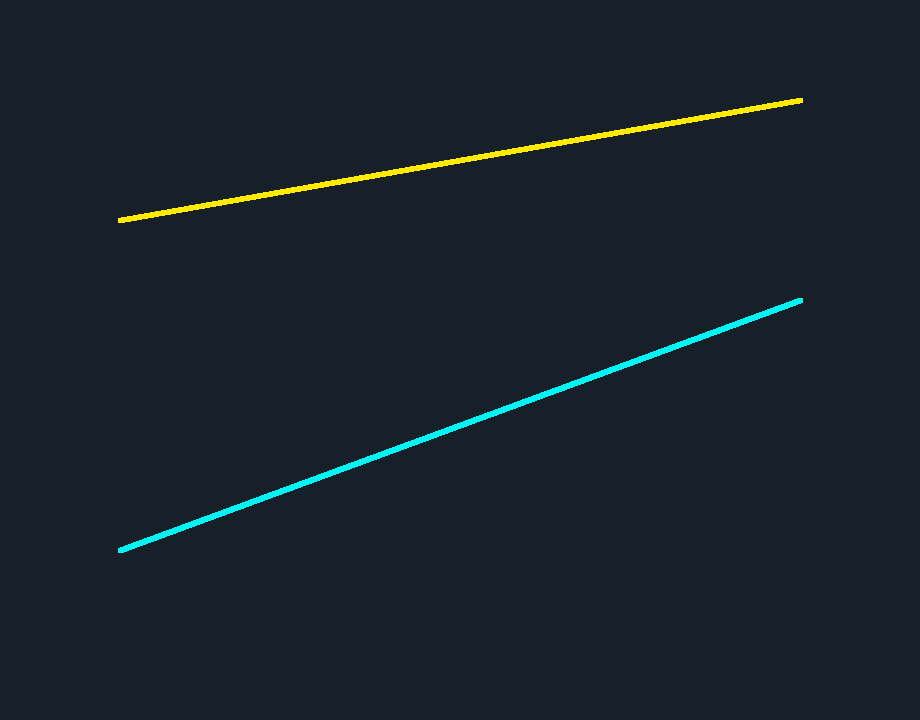

Saved as experiment1_dda_bresenham.png


In [ ]:
from PIL import Image, ImageDraw
from IPython.display import display

W, H = 920, 720
img = Image.new('RGB', (W, H), (23, 31, 40))
draw = ImageDraw.Draw(img)

def draw_pixels(points, color, size=5):
    r = size // 2
    for x, y in points:
        sy = H - y
        draw.rectangle((x-r, sy-r, x+r, sy+r), fill=color)

draw_pixels(dda, (0, 245, 245), 5)
draw_pixels(bres, (255, 235, 0), 5)

img.save('experiment1_dda_bresenham.png')
display(img)
print('Saved as experiment1_dda_bresenham.png')


### Output
**Cyan:** DDA line  
**Yellow:** Bresenham line

### Result
DDA and Bresenham line drawing algorithms were implemented successfully.